# Bai thuc hanh phan mo hinh PERCEPTRON

## Vi du 1:
- Xây dựng mô hình Perceptron từ các thư viện cơ sở và thực hiện phân loại dữ liệu nhân tạo để
minh họa. Trong ví dụ này, chúng ta sẽ tạo một tập dữ liệu ngẫu nhiên 02 chiều, với phân bố chuẩn có kỳ
vọng là các điểm tương đối biệt lập và ma trận hiệp phương sai phù hợp để đám bảo dữ liệu hầu như tách
được tuyến tính. Dưới đây là đoạn chương trình liên kết các thư viện và tạo dữ liệu:

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(2)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 30
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T
X = np.concatenate((X0, X1), axis = 1)

y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
# Xbar tạo một cột bias toàn số một vào bên trái mma trận X
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)


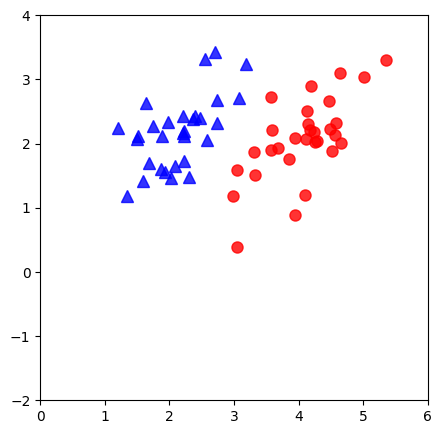

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ani = plt.cla()
#plot points
ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize = 8, alpha = .8)
ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize = 8, alpha = .8)
ani = plt.axis([0 , 6, -2, 4])
plt.show()

- Xây dựng hàm y = hw(x) = w0 + wTx = ẅTẍ

In [ ]:
# Define h_w(x):= W^T.x + w_0 = \bar{W}^T . \bar{x}
def h(w, x):
    # hàm sign có giá trị là 1 hoặc -1
    return np.sign(np.dot(w.T, x))

- Ham kiem tra dieu kien dung

In [ ]:
#Stop condition
def has_converged(X, y, w):
    # điều kiện dừng khi sing(w.t*x) == y
    return np.array_equal(h(w, X), y) #True if h(w, X) == y else False

- Vòng lặp chính tìm đường phân chia (bộ hệ số W) theo phương pháp Gradient Descent

In [ ]:
def perceptron(X, y, w_init):
    w = [w_init] # khởi tạo trọng số
    N = X.shape[1] # lấy ra số lượng cột của X
    mis_points = [] # set of miss position points
    while True:
        # mix data, tạo radom một vecto từ 0 -> N - 1
        # Giúp đường w cập nhật một cách trung thưc hơn, dễ hội tụ hơn
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)
        if has_converged(X, y, w[-1]):
            break
    return (w, mis_points)

- Gọi hàm lặp và in ra kết quả là bộ trọng số W ở vòng lặp cuối

In [18]:
d = X.shape[0]
w_init = np.random.randn(d, 1) # khởi tạo trọng só
(w, m) = perceptron(X, y, w_init)
print(w[-1])

[[ 13.97858527]
 [-15.02901929]
 [ 14.38743059]]


- Tiếp theo chúng ta xây dựng phương thức vẽ đường phân chia để quan sát kết quả

In [19]:
def draw_line(w):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        return plt.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
        return plt.plot([x10, x10], [-100, 100], 'k')

- Trong phần cuối, chúng ta sẽ hiển thị kết quả dạng ảnh động (gif) để quan sát sự thay đổi của đường phân
chia qua từng bước lặp. Tên ảnh kết quả sẽ là 'pla_vis.gif', trong chương trình này ảnh được lưu vào ổ
D:\. Các bạn sửa đường dẫn. Khi chương trình kết thúc đường phân chia cuối cùng sẽ được vẽ ra. Chúng
ta sử dụng thư viện matplotlib.animation để tạo gif

In [20]:
# Visualization
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

def viz_alg_1d_2(w):
    it = len(w)
    fig, ax = plt.subplots(figsize=(5,5))
    
    def update(i):
        ani = plt.cla()
        #points 
        ani = plt.plot(X0[0, :], X0[1, :], 'b^', markersize =  8, alpha = .8)
        ani = plt.plot(X1[0, :], X1[1, :], 'ro', markersize =  8, alpha = .8)
        ani = plt.axis([0 , 6, -2, 4])
        i2 = i if i < it else it-1
        ani = draw_line(w[i2])
        if i < it-1:
            # draw one misclassified point
            circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill =
            False)
            ax.add_artist(circle)
        # hide axis
        cur_axes = plt.gca()
        cur_axes.axes.get_xaxis().set_ticks([])
        cur_axes.axes.get_yaxis().set_ticks([])
        label = 'PLA: iter %d/%d' %(i2, it-1)
        ax.set_xlabel(label)
        return ani, ax
    anim = FuncAnimation(fig, update, frames=np.arange(0, it + 2), interval=1000)
    # save
    anim.save('/home/datbritget/Downloads/perceptron.gif', dpi = 100, writer = 'imagemagick')
    plt.show()

# viz_alg_1d_2(w)

## Vi du 2:
- Trong ví dụ dưới đây chúng ta sử dụng dữ liệu sóng thủy âm Sonar. Tệp dữ liệu có 60 cột ứng
với 60 thuộc tính (trường) không có tiêu đề, là tham số của các mẫu sóng âm phản hồi; cột thứ 61 là đầu
ra phân loại (y), với ký tự “R” nghĩa là Rock; ký tự “M” nghĩa là Mine (vật thể kim loại hình trụ). Toàn
bộ tệp có 208 bản ghi. Thông tin thêm về dữ liệu có thể tìm hiểu tại link
https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks) hoặc có thể lấy
trong tệp Sonar.all-data.csv đính kèm

- Trong ví dụ này chúng ta sử dụng thư viện matplotlib và seaborn để thực hiện việc hiển thị trực quan cấu
trúc dữ liệu (tham khảo lại bài thực hành phần PCA)

In [21]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
main_df = pd.read_csv('sonar.all-data.csv', header = None)
main_df

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


- Chúng ta sẽ kiểm tra độ cân bằng của dữ liệu bằng cách nhóm theo cột cuối cùng (chỉ số cột là 60 – tính
từ không), tức là cột đầu ra y:

<Axes: ylabel='60'>

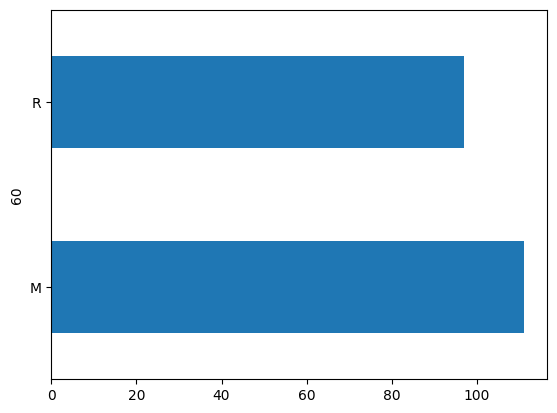

In [24]:
main_df[60].value_counts().plot(kind = 'barh')

In [26]:
y_df = main_df[60]
targes_label = {'M':1, 'R':-1}
targes_df = [targes_label[item] for item in y_df]
#targes_df = y_df.mix({'M':1, 'R':1})

print(targes_df)

[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


- lay phan du lieu quan sat (bo cot 60)

In [27]:
inputs_df = main_df.drop(60, axis=1)

- Sau do bo sung them truong du lieu x0 = 1 vao ben trai

In [28]:
inputs_df = main_df.drop(60, axis=1)
x0 = np.ones(( inputs_df.shape[0], 1))
X = np.concatenate((x0, inputs_df), axis = 1)

- Số chiều dữ liệu hiện tại sẽ là 61 (trường) x 208 (bản ghi). Chúng ta chia dữ liệu thành tập train : test với
tỷ lệ là 7:3


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, targes_df, test_size=0.30,
random_state=42)

### Bai tap thuc hanh
#### a. 
- Tiếp theo, các bạn hãy sử dụng các hàm đã có ở Ví dụ 1, sau đó huấn luyện mô hình bằng tập dữ
liệu X_train, y_train. Chú ý chúng ta cần bỏ qua các phần lệnh phục vụ việc hiển thị kết quả dạng
hình vẽ.

In [72]:
def h(w, x):
    return np.sign(np.dot(w.T, x))

In [73]:
def has_converged(X, y, w):
    return np.array_equal(h(w, X.T), y)

In [80]:
def perceptron(X, y, w_init, max_epochs=100):
    w = [w_init] # 61 x 1
    N = X.shape[0] #145
    mis_points = []
    epoch = 0
    while epoch < max_epochs:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[mix_id[i], :].reshape(1, -1).T # 1 x 61
            yi = y[mix_id[i]] #145
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi * xi
                w.append(w_new)
        
        # X: 145 x 61, w 1x61
        if has_converged(X, y, w[-1]):
            break
        
        epoch += 1
        
    if epoch == max_epochs:
        print(f"Đã chạm ngưỡng tối đa {max_epochs} vòng lặp, mô hình chưa hội tụ 100%.")
        
    return (w, mis_points)
                

In [91]:
d = X_train.shape[1]

w_init = np.random.randn(d, 1)
(w, m) = perceptron(X_train, y_train, w_init)
print(w[-1])

Đã chạm ngưỡng tối đa 100 vòng lặp, mô hình chưa hội tụ 100%.
[[-19.02607518]
 [  9.46872918]
 [  3.46939499]
 [ -4.17481466]
 [ 26.51375461]
 [ 19.73373996]
 [ -3.77388522]
 [-13.32146174]
 [-13.7530922 ]
 [ 12.61893745]
 [ -2.69222267]
 [ 26.10896691]
 [ 18.61161207]
 [ -6.43718732]
 [ -5.28948567]
 [  3.05324262]
 [ -9.72628348]
 [  3.363927  ]
 [  1.39752654]
 [  4.13177675]
 [  0.1927086 ]
 [ -0.48529509]
 [  4.98102089]
 [ -5.34059033]
 [ 11.69814073]
 [ -4.19654917]
 [ -0.34754861]
 [ -0.35333049]
 [  4.08016513]
 [ -2.38595062]
 [ 18.31082264]
 [-29.27955738]
 [  9.12254141]
 [ 11.5582625 ]
 [-11.60837386]
 [ -0.45611688]
 [ -4.70951285]
 [-13.64055275]
 [  2.08095273]
 [ 12.92739974]
 [-19.308968  ]
 [ -0.4598032 ]
 [ -1.5014398 ]
 [ 16.90386952]
 [  4.50583973]
 [ 10.13719377]
 [ 14.92683821]
 [  1.19334587]
 [ 14.76318482]
 [ 15.95903112]
 [ -2.24562067]
 [  4.2951512 ]
 [  2.8746    ]
 [  1.55803003]
 [  5.31691215]
 [ -0.29372502]
 [ -2.3827376 ]
 [ -0.60460221]
 [  2.0885

#### b. 
- Sau đó, hãy viết bổ sung phần chương trình thực hiện việc chạy test với bộ hệ số đã có, tham khảo
các bài phần trước và tính độ chính xác bằng accuracy, recall và và precision.

In [118]:

import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

start_time_a = time.time()


# --- PHẦN B: Hàm dự đoán và tính độ đo ---
def predict_manual(X, w):
    y_pred = np.sign(np.dot(X, w))
    y_pred[y_pred == 0] = -1 # Mặc định là Rock nếu bằng 0
    return y_pred

y_pred_manual = predict_manual(X_test, w[-1])
time_a = time.time() - start_time_a

def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    return acc, prec, rec

acc_a, prec_a, rec_a = evaluate(y_test, y_pred_manual)



#### c. Vẫn phân chia bộ dữ liệu như trong ý trên, sau đó thực nghiệm dự đoán trên các tập với mô hình Logistic và Naïve Bayess phù hợp. So sánh kết quả của các phương pháp dựa trên thời gian chạy
- (cho toàn tập train/test), độ chính xác với các độ đo như ở ý b)

In [124]:


# 1. Logistic Regression
lr_model = LogisticRegression(fit_intercept=False, max_iter=1000)
start_lr = time.time()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
time_lr = time.time() - start_lr
acc_lr, prec_lr, rec_lr = evaluate(y_test, y_pred_lr)

# 2. Naive Bayes (Sử dụng dữ liệu gốc không có cột x0=1 vì NB không nhận biến hằng số)
X_train_nb = X_train[:, 1:]
X_test_nb = X_test[:, 1:]
nb_model = GaussianNB()
start_nb = time.time()
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
time_nb = time.time() - start_nb
acc_nb, prec_nb, rec_nb = evaluate(y_test, y_pred_nb)

# --- TỔNG HỢP KẾT QUẢ ---
results = {
    "Mô hình": ["Perceptron (Manual)", "Logistic Regression", "Naive Bayes"],
    "Accuracy": [acc_a, acc_lr, acc_nb],
    "Precision": [prec_a, prec_lr, prec_nb],
    "Recall": [rec_a, rec_lr, rec_nb],
    "Thời gian chạy (s)": [time_a, time_lr, time_nb]
}
compare_df = pd.DataFrame(results)
print(compare_df)

               Mô hình  Accuracy  Precision    Recall  Thời gian chạy (s)
0  Perceptron (Manual)  0.809524   0.870968  0.771429            0.000464
1  Logistic Regression  0.825397   0.800000  0.914286            0.004074
2          Naive Bayes  0.777778   0.920000  0.657143            0.001001


## Vi du 3
-  Xét tập dữ liệu phân loại bệnh nhân ung thư vú của Đại học Wisconsin–Madison, Hoa Kỳ. Dữ
liệu có sẵn trong thư viện sklearn.
Dữ liệu có 569 bản ghi (mẫu), với 30 thuộc tính. Bệnh nhân được chia làm hai loại: u lành tính (B –
Begnin) có 357 mẫu và u ác tính (M – Malignant) có 212 mẫu.

In [179]:
from sklearn import datasets
cancer_data = datasets.load_breast_cancer()
# show to test record 5th
print(cancer_data.data[5])

#target set
from sklearn.model_selection import train_test_split

cancer_data = datasets.load_breast_cancer()
x0 = np.ones((cancer_data.data.shape[0], 1))
cancer_df = np.concatenate((x0, cancer_data.data), axis = 1)
X_train, X_test, y_train, y_test = train_test_split(cancer_df,
                cancer_data.target, test_size=0.3,random_state=109)

y_train_p = np.where(y_train == 0, -1, 1)
y_test_p = np.where(y_test == 0, -1, 1)
print(cancer_data.target.shape)
print(cancer_df.shape)

[1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]
(569,)
(569, 31)


#### Bai tap thuc hanh
- Thực hiện các bước tương tự như yêu cầu của Ví dụ 2. Sử dụng lại dữ liệu trong
ví dụ 2 và ví dụ 3, sau đó

- Thực hiện giảm số chiều về 02 chiều
- Hiển thị kết quả dữ liệu đã giảm chiều lên màn hình, với 2 phân lớp được biểu diễn bằng 2 màu
khác nhau.
- Thực hiện phân loại bằng hồi quy Logistic và so sánh kết quả với phương pháp Perceptron đã
thực hiện ở phần trước.

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [181]:
# Huan luyen mo hinh bang tap du lieu X_train, y_train
def h(w, x):
    return np.sign(np.dot(w.T, x))

def has_converged(X, y, w):
    return np.array_equal(h(w, X.T), y)

def perceptron(X, y, w_init, max_epochs=100):
    w = [w_init] # 61 x 1      # phải là (31, 1)
    N = X.shape[0] #145
    mis_points = []
    epoch = 0
    while epoch < max_epochs:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[mix_id[i], :].reshape(1, -1).T # 1 x 61
            yi = y[mix_id[i]] #145
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi * xi
                w.append(w_new)
        
        # X: 145 x 61, w 1x61
        if has_converged(X, y, w[-1]):
            break
        
        epoch += 1
        
    if epoch == max_epochs:
        print(f"Đã chạm ngưỡng tối đa {max_epochs} vòng lặp, mô hình chưa hội tụ 100%.")
        
    return (w, mis_points)
                


In [182]:
d = X_train.shape[1]

w_init = np.random.randn(d, 1)
(w, m) = perceptron(X_train, y_train_p, w_init)
print(w[-1])


Đã chạm ngưỡng tối đa 100 vòng lặp, mô hình chưa hội tụ 100%.
[[ 5.70373644e+02]
 [ 4.35230827e+03]
 [ 9.84895458e+01]
 [ 2.20338642e+04]
 [ 4.06063131e+03]
 [ 1.47783983e+01]
 [-1.17477575e+02]
 [-2.15425488e+02]
 [-8.89623547e+01]
 [ 3.08390858e+01]
 [ 1.90813748e+01]
 [ 1.41374244e+01]
 [-8.66183455e+01]
 [-5.89835390e+02]
 [-1.20753015e+04]
 [-6.37959294e-01]
 [-3.81647460e+01]
 [-4.89219145e+01]
 [-1.11772341e+01]
 [-2.28871746e+00]
 [-3.19837347e+00]
 [ 4.67443822e+03]
 [-2.41967849e+03]
 [ 1.95602331e+04]
 [-8.10218655e+03]
 [ 7.43160760e-01]
 [-4.29492505e+02]
 [-6.00043060e+02]
 [-1.58117172e+02]
 [-1.66738836e+01]
 [-1.22729515e+01]]


In [183]:
def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    return acc, prec, rec

In [184]:
# Viet chuogn trinh bo sung tuc hien chay test vơi hệ số đã cos
start_time_a = time.time()

def predict(X, w):
    y_pred = np.sign(np.dot(X, w))
    y_pred[y_pred == 0] = -1
    return y_pred

y_pred = predict(X_test, w[-1])
time_a = time.time() - start_time_a

acc_a, prec_a, rec_a = evaluate(y_test_p, y_pred)
print("accuracy:", acc_a)
print("prec", prec_a)
print("rec", rec_a)

accuracy: 0.9298245614035088
prec 0.9615384615384616
rec 0.9259259259259259


In [191]:

# Thực hiện dữ đoán trên mô hình Logistic và naive bayes phù hợp.
# So sánh kết quả và phương pháp dựa trên thời gian chạy

# logistic regression
lr_model = LogisticRegression(fit_intercept=False, max_iter = 1000)
start = time.time()
lr_model.fit(X_train, y_train_p)
y_pred_lr = lr_model.predict(X_test)
time_lr = time.time() - start
acc_lr, prec_lr, rec_lr = evaluate(y_test_p, y_pred_lr)

# naive bayess
X_train_nb = X_train[:, 1:]
X_test_nb = X_test[:, 1:]
nb_model = GaussianNB()
start_time = time.time()
nb_model.fit(X_train_nb, y_train_p)

y_pred_nb = nb_model.predict(X_test_nb)

acc_nb, prec_nb, rec_nb = evaluate(y_test_p, y_pred_nb)

# --- TỔNG HỢP KẾT QUẢ ---
results = {
    "Mô hình": ["Perceptron (Manual)", "Logistic Regression", "Naive Bayes"],
    "Accuracy": [acc_a, acc_lr, acc_nb],
    "Precision": [prec_a, prec_lr, prec_nb],
    "Recall": [rec_a, rec_lr, rec_nb],
    "Thời gian chạy (s)": [time_a, time_lr, time_nb]
}
compare_df = pd.DataFrame(results)
print(compare_df)


               Mô hình  Accuracy  Precision    Recall  Thời gian chạy (s)
0  Perceptron (Manual)  0.929825   0.961538  0.925926            0.000000
1  Logistic Regression  0.970760   0.981308  0.972222            0.115177
2          Naive Bayes  0.953216   0.946429  0.981481            0.116817


In [192]:
# Thực hiện giảm số chiều
from sklearn.decomposition import PCA

# bỏ cột bias trước khi PCA
X_train_raw = X_train[:, 1:]
X_test_raw = X_test[:, 1:]

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_raw)
X_test_2d  = pca.transform(X_test_raw)

print(f"Phương sai giữ lại: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Phương sai giữ lại: 99.80%


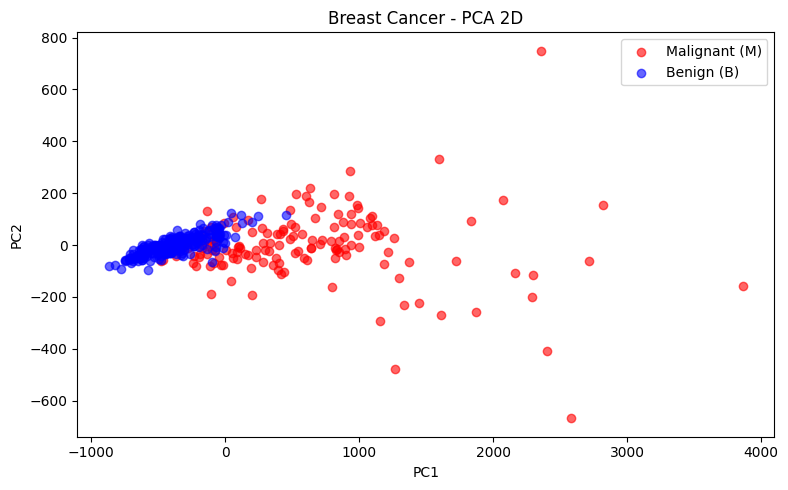

In [193]:
# Hiển thị két quả trực quan hóa lên mà hình
plt.figure(figsize=(8, 5))
plt.scatter(X_train_2d[y_train_p == -1, 0], X_train_2d[y_train_p == -1, 1],
            c='red',  label='Malignant (M)', alpha=0.6)
plt.scatter(X_train_2d[y_train_p ==  1, 0], X_train_2d[y_train_p ==  1, 1],
            c='blue', label='Benign (B)',    alpha=0.6)
plt.title('Breast Cancer - PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

In [194]:
# Thực hiện phân loại hồi quy logistic và so sánh kết quả với pp perceptron đã thực hiên 
# ở phần trước

def add_bias(X):
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

X_train_2d_b = add_bias(X_train_2d)  # (N_train, 3)
X_test_2d_b  = add_bias(X_test_2d)   # (N_test,  3)

lr_2d = LogisticRegression(max_iter=1000)
start = time.time()
lr_2d.fit(X_train_2d, y_train_p)
y_pred_lr_2d = lr_2d.predict(X_test_2d)
time_lr_2d = time.time() - start

acc_lr_2d, prec_lr_2d, rec_lr_2d = evaluate(y_test_p, y_pred_lr_2d)


In [195]:
results = {
    "Mô hình": ["Perceptron (Manual)", "Logistic Regression"],
    "Accuracy": [acc_a, acc_lr_2d],
    "Precision": [prec_a, prec_lr_2d],
    "Recall": [rec_a, rec_lr_2d],
    "Thời gian chạy (s)": [time_a, time_lr_2d]
}
compare_df = pd.DataFrame(results)
print(compare_df)

               Mô hình  Accuracy  Precision    Recall  Thời gian chạy (s)
0  Perceptron (Manual)  0.929825   0.961538  0.925926            0.000000
1  Logistic Regression  0.964912   0.963636  0.981481            0.006513


## Vi du 4 (Bai tap thuc hanh):
- Chúng ta sử dụng lại dữ liệu chứa các thông tin về nhân khẩu, hành vi
thói quen và lịch sử bệnh lý để xác định khả năng bị trụy tim ở một bệnh nhân đã cho trong phần thực
hành hồi quy Logistic. Mục tiêu phân loại là dự đoán liệu bệnh nhân có nguy cơ mắc bệnh tim mạch vành
(CHD) trong tương lai (10 năm) hay không. Bộ dữ liệu cung cấp thông tin của bệnh nhân, có thể tìm thấy
tại link https://www.kaggle.com/amanajmera1/framingham-heart-study-dataset/data hoặc lấy từ tệp đính
kèm framingham.csv trong bài thực hành hồi quy Logistic.

##### 1) Giảm số chiều dữ liệu xuống còn 02 chiều và tìm cách hiển thị trực quan dữ liệu sau khi giảm chiều

##### 2) Hãy xử lý sơ bộ dữ liệu như trong yêu cầu của phần hồi quy logistic, sử dụng các biện pháp chuyển đổi dữ liệu hợp lý. Chia tập dữ liệu thành Traning:Validation = 7:3. Sau đó
- a. Thực hiện phân loại bằng phương pháp Perceptron. Tính các độ đo Accuracy, Precision
và Recall để đánh giá kết quả. Giải thích về ý nghĩa của các hệ số của mô hình.
- b. Thực hiện phân loại bằng phương pháp Hồi quy Logistic trên cùng bộ dữ liệu
training:validation đã có ở ý trên. Tính các độ đo Accuracy, Precision và Recall và giải
thích về ý nghĩa của các hệ số của mô hình.
- c. Lựa chọn phương pháp Naïve Bayess phù hợp, sau đó sử dụng để thực hiện phân loại bộ
dữ liệu đã có trong ý a. và b. Tính các độ đo Accuracy, Precision và Recall.
So sánh độ chính xác của mỗi mô hình.

##### 3) Hãy thực hiện lại câu 2) với dữ liệu đã giảm chiều thu được ở câu 1). Hãy giải thích về kết quả thu được của các mô hình cũng như nhận xét trên độ chính xác của mỗi mô hình. Cho biết mô hình nào chịu ảnh hưởng nhiều nhất khi giảm chiều dữ liệu.

## Vi du 5 (Bai tap thuc hanh)
- Trong tệp Analysis-Portfolio-Task-Data.csv đính kèm chứa 75 bản ghi
chứa thông tin về các hóa đơn mua sắm của khách hàng mà nhóm quản lý tiếp thị của hệ thống siêu thị
Fresco thu thập đối với một số chủ thẻ khách hàng thân thiết của họ trong khoảng thời gian 26 tuần. Các
trường dữ liệu gồm: CustomerID – Mã khách hàng – trường này không đưa vào mô hình tính toán;
Shopping Basket (Giá trị của giỏ hàng khách mua); Gender (Giới tính); Age (độ tuổi); Store Type
(Kiểu cửa hàng); Value Products (Số sản phẩm có giá trị cao trong giỏ hàng); Brand Products (Số
sản phẩm có thương hiệu nối tiếng trong giỏ hàng); Top Fresco Products (Số sản phẩm của chính hệ
thống siêu thi được đánh giá cao).
Trong số này, Gender gồm male và female (thông tin cần được chuẩn hóa) và Store Type gồm
convenience stores (cửa hàng tiện lợi), superstores (siêu thị) và online.

#### 1) Hãy chuẩn hóa thông tin và đưa các trường về dạng số một cách phù hợp. 
- Sau đó coi Shopping Basket là đầu ra (y), hãy sử dụng các biến còn lại như đầu vào và sử dụng mô hình hồi quy tuyến tính, với 60 bản ghi đầu là phần training và 15 bản ghi còn lại là validation. Thực hiện huấn luyện và dự báo trên tập validation, cho biết độ chính xác và hệ số của mô hình. Giải thích ý nghĩa của các hệ số đó cũng như kết quả.